<a href="https://colab.research.google.com/github/abhishekanand04/DAV---Fundamentals/blob/fundamentals/T_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

A french cake shop claims that the average number of pastries they can produce in a day exceeds 500.
The average number of pastries produced per day over a 70 day period was found to be 530.
Assume that the population standard deviation for the pastries produced per day is 125.

Test the claim using a z-test with the critical z-value = 1.64 at the alpha (significance level) = 0.05, and state your interpretation.

In [ ]:
# 1. What should be the null and alternate hypothesis?

# H0 : mu = 500
# Ha : mu > 500

In [ ]:
# 2. Choosing the right test statistic and its distribution.

sd_population = 125
sd_sample = sd_population / np.sqrt(70)

In [ ]:
# 3. Left side or Right side or Two-tailed?

# Right Tailed Test

In [ ]:
# 4. Calculating P-value

z = (530 - 500) / sd_sample
z

2.007984063681781

In [ ]:
from scipy.stats import norm

pvalue = 1 - norm.cdf(z)
pvalue

0.022322492581293485

In [ ]:
# 5. Compare with significance level alpha

alpha = 0.05

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Reject H0


In [ ]:
z = norm.ppf(0.95)
z

1.6448536269514722

In [ ]:
x = z * sd_sample + 500
x

524.574701413748

In [ ]:
# Sample mean = 520

z = (520 - 500) / sd_sample
z

1.3386560424545209

In [ ]:
pvalue = 1 - norm.cdf(z)
pvalue

0.09034133632880059

In [ ]:
alpha = 0.05

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Fail to Reject H0


In [ ]:
z = norm.ppf(0.99)
z

2.3263478740408408

In [ ]:
x = z * sd_sample + 500
x

534.7564691789732

In [ ]:
from scipy.stats import ttest_1samp

# The pill is given to a few people and their IQ is tested with following results:
iq_scores = [110, 105, 98, 102, 99, 104, 115, 95]

t_stat, pvalue = ttest_1samp(iq_scores, 100)  # (Sample, mu)
t_stat, pvalue

(1.5071573172061195, 0.1754994493585011)

In [ ]:
alpha = 0.01 # 99% confidence

if pvalue < alpha:
  print('Reject H0; Pill has effect')
else:
  print ('Fail to Reject H0; Pill has NO effect')

Fail to Reject H0; Pill has NO effect


In [ ]:
# Suppose we have IQ data samples across 2 schools,
# and we want to compare and see which school's students have better IQ

# alpha = 0.05

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1qSiKRk_9fNmTWsEDWqOygwcGrU-XuINw -O iq_two_schools.csv


--2025-01-03 16:31:12--  https://drive.google.com/uc?id=1qSiKRk_9fNmTWsEDWqOygwcGrU-XuINw
Resolving drive.google.com (drive.google.com)... 142.250.65.110, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|142.250.65.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1qSiKRk_9fNmTWsEDWqOygwcGrU-XuINw [following]
--2025-01-03 16:31:12--  https://drive.usercontent.google.com/download?id=1qSiKRk_9fNmTWsEDWqOygwcGrU-XuINw
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:815::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 639 [application/octet-stream]
Saving to: ‘iq_two_schools.csv’

iq_two_schools.csv  100%[===================>]     639  --.-KB/s    in 0s      

2025-01-03 16:31:14 (34.0 MB/s) - ‘iq_two_schools.c

In [ ]:
import pandas as pd

df_iq = pd.read_csv('/content/iq_two_schools.csv')
df_iq.head()


,School,iq
0,school_1,91
1,school_1,95
2,school_1,110
3,school_1,112
4,school_1,115


In [ ]:
df_iq.groupby('School')['iq'].mean()

,iq
School,
school_1,101.153846
school_2,109.416667


In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 <> mu2

from scipy.stats import ttest_ind

In [ ]:
iq_1 = df_iq[df_iq['School'] == 'school_1']['iq']
iq_2 = df_iq[df_iq['School'] == 'school_2']['iq']

In [ ]:
t_stat, pvalue = ttest_ind(iq_1, iq_2)  # (Sample 1, Sample 2)
t_stat, pvalue

(-2.4056474861512704, 0.02004552710936217)

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Reject H0


In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 > mu2

t_stat, pvalue = ttest_ind(iq_1, iq_2, alternative = "greater")
t_stat, pvalue

(-2.4056474861512704, 0.9899772364453189)

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Fail to Reject H0


In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 < mu2

t_stat, pvalue = ttest_ind(iq_1, iq_2, alternative = "less")    # greater -> less
t_stat, pvalue

(-2.4056474861512704, 0.010022763554681085)

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Reject H0


In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1bvVVbWUu6JKQDol0xwj3pqsTs4Qxm_oj -O Sachin_ODI.csv

--2025-01-03 16:55:19--  https://drive.google.com/uc?id=1bvVVbWUu6JKQDol0xwj3pqsTs4Qxm_oj
Resolving drive.google.com (drive.google.com)... 142.250.65.110, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|142.250.65.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1bvVVbWUu6JKQDol0xwj3pqsTs4Qxm_oj [following]
--2025-01-03 16:55:19--  https://drive.usercontent.google.com/download?id=1bvVVbWUu6JKQDol0xwj3pqsTs4Qxm_oj
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:815::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26440 (26K) [application/octet-stream]
Saving to: ‘Sachin_ODI.csv’

Sachin_ODI.csv      100%[===================>]  25.82K  --.-KB/s    in 0.002s  

2025-01-03 16:55:22 (10.5 MB/s) - ‘Sachin_ODI.c

In [ ]:
df = pd.read_csv('/content/Sachin_ODI.csv')
df

,runs,NotOut,mins,bf,fours,sixes,sr,Inns,Opp,Ground,Date,Winner,Won,century
0,13,0,30,15,3,0,86.66,1,New Zealand,Napier,1995-02-16,New Zealand,False,False
1,37,0,75,51,3,1,72.54,2,South Africa,Hamilton,1995-02-18,South Africa,False,False
2,47,0,65,40,7,0,117.50,2,Australia,Dunedin,1995-02-22,India,True,False
3,48,0,37,30,9,1,160.00,2,Bangladesh,Sharjah,1995-04-05,India,True,False
4,4,0,13,9,1,0,44.44,2,Pakistan,Sharjah,1995-04-07,Pakistan,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,14,0,34,15,2,0,93.33,2,Australia,Sydney,2012-02-26,Australia,False,False
356,39,0,45,30,5,0,130.00,2,Sri Lanka,Hobart,2012-02-28,India,True,False
357,6,0,25,19,1,0,31.57,1,Sri Lanka,Dhaka,2012-03-13,India,True,False
358,114,0,205,147,12,1,77.55,1,Bangladesh,Dhaka,2012-03-16,Bangladesh,False,True


In [ ]:
df.groupby('Inns')['runs'].mean()

,runs
Inns,
1,46.670588
2,40.173684


In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 > mu2

df_1_runs = df[df['Inns'] == 1]['runs']
df_2_runs = df[df['Inns'] == 2]['runs']

In [ ]:
t_stat, pvalue = ttest_ind(df_1_runs, df_2_runs, alternative = "greater")
t_stat, pvalue

(1.4612016295532178, 0.07241862097379981)

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
  print('First innings is better')
else:
  print ('Fail to Reject H0')
  print('Difference we observe is just chance')

Fail to Reject H0
Difference we observe is just chance


In [ ]:
df.groupby('Won')['runs'].mean()

,runs
Won,
False,35.130682
True,51.000000


In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 > mu2    mu1: Won, mu2: Lost

df_won = df[df['Won'] == True]
df_lost = df[df['Won'] == False]

In [ ]:
t_stat, pvalue = ttest_ind(df_won['runs'], df_lost['runs'], alternative = "greater")
t_stat, pvalue

(3.628068563969343, 0.00016353077486826558)

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
  print('Better scores when team won the match')
else:
  print ('Fail to Reject H0')
  print('Difference we observe is just chance')

Reject H0
Better scores when team won the match


In [ ]:
alpha = 0.01 # 99% confidence

if pvalue < alpha:
  print('Reject H0')
  print('Better scores when team won the match')
else:
  print ('Fail to Reject H0')
  print('Difference we observe is just chance')

Reject H0
Better scores when team won the match


In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1aTrYo2_PIeYcg8Fvpr5m2GYAXiPvvOmz -O drug_1_recovery.csv

--2025-01-03 17:11:02--  https://drive.google.com/uc?id=1aTrYo2_PIeYcg8Fvpr5m2GYAXiPvvOmz
Resolving drive.google.com (drive.google.com)... 142.250.65.110, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|142.250.65.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1aTrYo2_PIeYcg8Fvpr5m2GYAXiPvvOmz [following]
--2025-01-03 17:11:02--  https://drive.usercontent.google.com/download?id=1aTrYo2_PIeYcg8Fvpr5m2GYAXiPvvOmz
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:815::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1102 (1.1K) [application/octet-stream]
Saving to: ‘drug_1_recovery.csv’

drug_1_recovery.csv 100%[===================>]   1.08K  --.-KB/s    in 0s      

2025-01-03 17:11:04 (43.8 MB/s) - ‘drug_1_

In [ ]:
d1 = pd.read_csv('/content/drug_1_recovery.csv')
d1

,drug_1
0,8.824208
1,7.477745
2,7.557121
3,7.981314
4,6.827716
...,...
95,6.890506
96,7.725759
97,6.848016
98,7.969997


In [ ]:
d1.mean()

,0
drug_1,7.104917


In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1YgAgnzkfiCFz_kSO6BPPLCYAB2K5VwXG -O drug_2_recovery.csv

--2025-01-03 17:12:41--  https://drive.google.com/uc?id=1YgAgnzkfiCFz_kSO6BPPLCYAB2K5VwXG
Resolving drive.google.com (drive.google.com)... 142.250.65.110, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|142.250.65.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1YgAgnzkfiCFz_kSO6BPPLCYAB2K5VwXG [following]
--2025-01-03 17:12:41--  https://drive.usercontent.google.com/download?id=1YgAgnzkfiCFz_kSO6BPPLCYAB2K5VwXG
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:815::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1328 (1.3K) [application/octet-stream]
Saving to: ‘drug_2_recovery.csv’

drug_2_recovery.csv 100%[===================>]   1.30K  --.-KB/s    in 0s      

2025-01-03 17:12:44 (65.9 MB/s) - ‘drug_2_

In [ ]:
d2 = pd.read_csv('/content/drug_2_recovery.csv')
d2

,drug_2
0,9.565974
1,7.492915
2,8.738418
3,7.635235
4,4.125593
...,...
115,7.861993
116,8.233510
117,5.876257
118,7.789454


In [ ]:
d2.mean()

,0
drug_2,8.073423


In [ ]:
d1.mean(), d2.mean()

(drug_1    7.104917
 dtype: float64,
 drug_2    8.073423
 dtype: float64)

In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 < mu2

t_stat, pvalue = ttest_ind(d1, d2, alternative = "less")
t_stat, pvalue

(array([-5.32112438]), array([1.27713574e-07]))

In [ ]:
alpha = 0.01 # 99% confidence

if pvalue < alpha:
  print('Reject H0')
  print('First drug has less recovery time.')
else:
  print ('Fail to Reject H0')
  print('Both have same recovery time')

Reject H0
First drug has less recovery time.


In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1fSKOoZcIfLTFMvyQ37RvGH168g5nVMDD -O aerofit.csv

--2025-01-03 17:19:56--  https://drive.google.com/uc?id=1fSKOoZcIfLTFMvyQ37RvGH168g5nVMDD
Resolving drive.google.com (drive.google.com)... 172.217.12.14, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|172.217.12.14|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1fSKOoZcIfLTFMvyQ37RvGH168g5nVMDD [following]
--2025-01-03 17:19:56--  https://drive.usercontent.google.com/download?id=1fSKOoZcIfLTFMvyQ37RvGH168g5nVMDD
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:815::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7461 (7.3K) [application/octet-stream]
Saving to: ‘aerofit.csv’

aerofit.csv         100%[===================>]   7.29K  --.-KB/s    in 0s      

2025-01-03 17:19:58 (62.5 MB/s) - ‘aerofit.csv’ save

In [ ]:
df = pd.read_csv('/content/aerofit.csv')
df

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


<Axes: xlabel='Gender', ylabel='Income'>

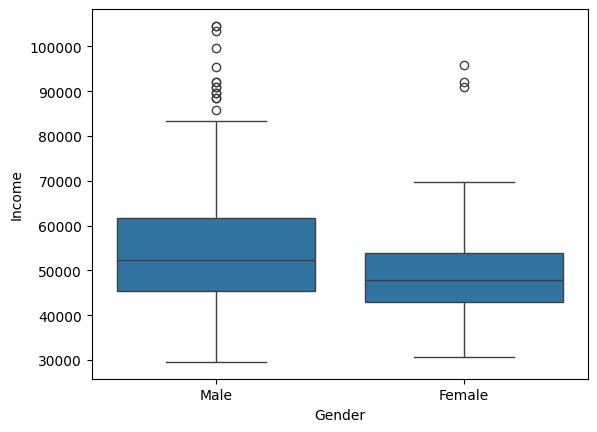

In [ ]:
sns.boxplot(x='Gender', y='Income', data=df)

In [ ]:
# H0 : mu1 = mu2
# Ha : mu1 > mu2    | mu1 -> male, mu2 -> female

income_male = df[df['Gender'] == 'Male']['Income']
income_female = df[df['Gender'] == 'Female']['Income']

In [ ]:
income_male.mean(), income_female.mean()

(56562.75961538462, 49828.90789473684)

In [ ]:
t_stat, pvalue = ttest_ind(income_male, income_female, alternative="greater")
pvalue

0.003263631548607129

In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
  print('Men earn more than females.')
else:
  print ('Fail to Reject H0')

Reject H0
Men earn more than females.


In [ ]:
# Will problem-solving sessions help students?

# Test 1: Before the session
# Test 2: After the session

from scipy.stats import ttest_rel
import pandas as pd

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1PZ1cC8nBZEtvnOYjfrg4xyErI-5i_-ae -O problem_solving.csv

--2025-01-03 17:33:19--  https://drive.google.com/uc?id=1PZ1cC8nBZEtvnOYjfrg4xyErI-5i_-ae
Resolving drive.google.com (drive.google.com)... 142.250.65.110, 2607:f8b0:4025:804::200e
Connecting to drive.google.com (drive.google.com)|142.250.65.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1PZ1cC8nBZEtvnOYjfrg4xyErI-5i_-ae [following]
--2025-01-03 17:33:19--  https://drive.usercontent.google.com/download?id=1PZ1cC8nBZEtvnOYjfrg4xyErI-5i_-ae
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.12.1, 2607:f8b0:4025:810::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.12.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1277 (1.2K) [application/octet-stream]
Saving to: ‘problem_solving.csv’

problem_solving.csv 100%[===================>]   1.25K  --.-KB/s    in 0s      

2025-01-03 17:33:21 (57.2 MB/s) - ‘problem

In [ ]:
Path= '/content/problem_solving.csv'
df_ps = pd.read_csv(Path)

len(df_ps)

137

In [ ]:
df_ps.head()

,id,test_1,test_2
0,0,40,38
1,1,49,44
2,2,65,69
3,3,59,63
4,4,44,43


In [ ]:
df_ps.describe()

,id,test_1,test_2
count,137.000000,137.000000,137.000000
mean,68.000000,60.489051,62.430657
std,39.692569,17.080311,17.516293
min,0.000000,30.000000,27.000000
25%,34.000000,46.000000,48.000000
50%,68.000000,59.000000,62.000000
75%,102.000000,75.000000,77.000000
max,136.000000,89.000000,96.000000


In [ ]:
# H0: Problem-solving has no effect
# Ha: Problem-solving had an effect

statistic, pvalue = ttest_rel(df_ps["test_1"], df_ps["test_2"])
print("Test statistic:",statistic)
print("pvalue:",pvalue)

Test statistic: -5.502886353508166
pvalue: 1.7958403537923126e-07


In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Reject H0


In [ ]:
# H0: Problem solving has no effect
# Ha: Problem solving improved the scores

statistic, pvalue = ttest_rel(df_ps["test_1"], df_ps["test_2"],alternative="less")
print("Test statistic:",statistic)
print("pvalue:",pvalue)

Test statistic: -5.502886353508166
pvalue: 8.979201768961563e-08


In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Reject H0


In [ ]:
# H0: Problem solving has no effect
# Ha: Problem solving deteriorated the scores

statistic, pvalue = ttest_rel(df_ps["test_1"], df_ps["test_2"],alternative="greater")
print("Test statistic:",statistic)
print("pvalue:",pvalue)

Test statistic: -5.502886353508166
pvalue: 0.9999999102079823


In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Fail to Reject H0
